# Import libraries and dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/investors.csv')
df.head(20)

,fixed_deposits,bonds,stocks,cryptocurrencies,class
0,19.07,9.02,6.95,1.66,0
1,37.67,10.58,3.41,1.79,0
2,30.66,7.56,20.76,12.04,1
3,30.19,18.78,31.21,15.10,1
4,11.27,19.28,4.01,1.80,0
5,21.72,27.22,7.47,0.62,0
6,40.37,12.28,4.71,1.72,0
7,37.90,14.07,19.98,10.15,1
8,34.84,9.93,10.59,0.70,0
9,34.94,22.58,7.22,0.55,0


# EDA

In [ ]:
df['class'].value_counts()

,count
class,
1,263
0,237


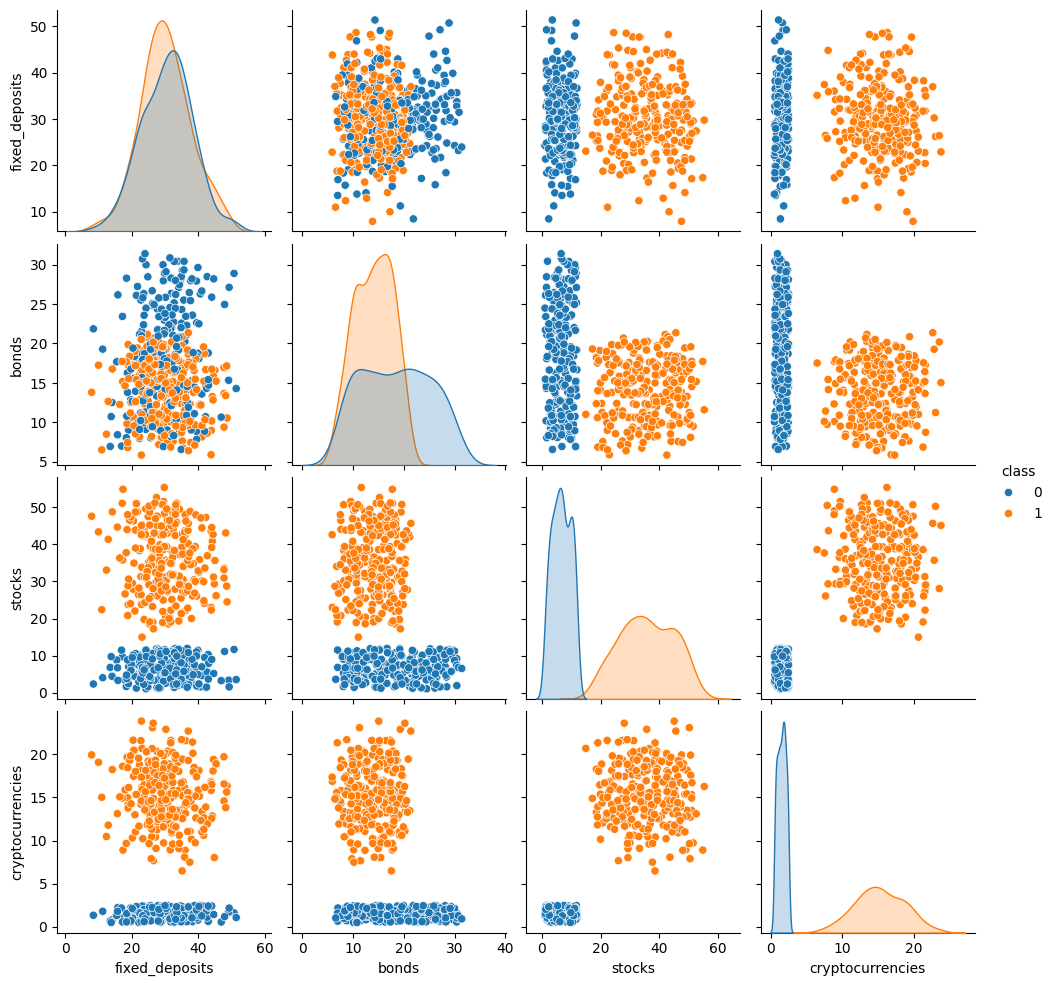

In [ ]:
sns.pairplot(df, hue='class')
plt.show()

# K-Means Clustering

In [ ]:
X = df.drop('class', axis=1)
y = df['class']

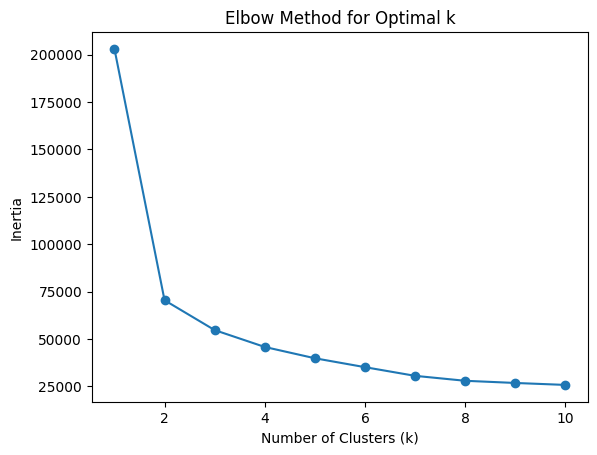

In [ ]:
from sklearn.cluster import KMeans

inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

K-means Silhouette Score: 0.5541
K-means Adjusted Rand Index: 0.9603


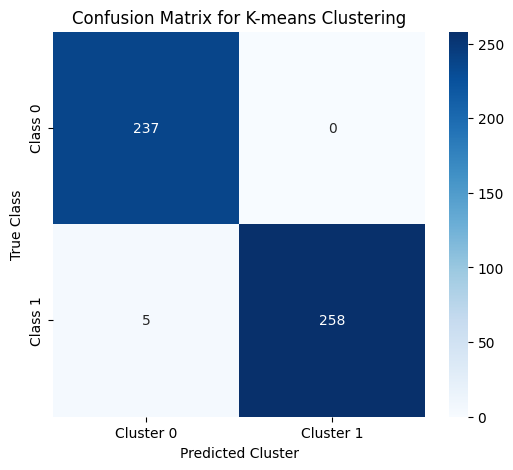

Homogeneity: 0.9296
Completeness: 0.9285
V-measure: 0.9291


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import homogeneity_score
from sklearn.metrics import completeness_score
from sklearn.metrics import v_measure_score

kmeans = KMeans(n_clusters=2)
kmeans_labels = kmeans.fit_predict(X)

kmeans_silhouette = silhouette_score(X, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print(f"K-means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"K-means Adjusted Rand Index: {kmeans_ari:.4f}")

cm = confusion_matrix(y, kmeans_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cluster 0', 'Cluster 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Cluster')
plt.ylabel('True Class')
plt.title('Confusion Matrix for K-means Clustering')
plt.show()

homogeneity = homogeneity_score(y, kmeans_labels)
completeness = completeness_score(y, kmeans_labels)
v_measure = v_measure_score(y, kmeans_labels)

print(f"Homogeneity: {homogeneity:.4f}")
print(f"Completeness: {completeness:.4f}")
print(f"V-measure: {v_measure:.4f}")

Accuracy: 0.994
Confusion Matrix:
Precision: 0.994075
Recall: 0.994
F1-score: 0.9940016595115264
True Positive Rates (TPRs): [1.0, 0.9885931558935361]
False Positive Rates (FPRs): [0.011406844106463879, 0.0]


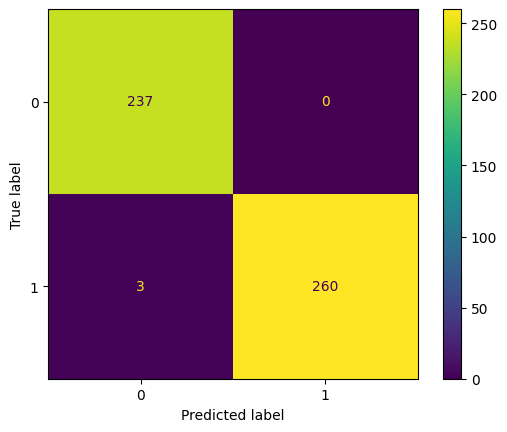

In [ ]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
klabels = kmeans.labels_

best_mapping = None
max_accuracy = 0
for mapping in [(0,1),(1,0)]:
    kmapped_labels = np.array([mapping[label] for label in klabels])
    accuracy = accuracy_score(y, kmapped_labels)
    if accuracy > max_accuracy:
        max_accuracy = accuracy
        best_mapping = mapping

kmapped_labels = np.array([best_mapping[label] for label in klabels])
print("Accuracy:", max_accuracy)

cm = confusion_matrix(y, kmapped_labels)
print("Confusion Matrix:")
precision = precision_score(y, kmapped_labels, average='weighted')
recall = recall_score(y, kmapped_labels, average='weighted')
f1 = f1_score(y, kmapped_labels, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

tprs = []
fprs = []
for i in range(2):
  tp = cm[i, i]
  fn = np.sum(cm[i, :]) - tp
  fp = np.sum(cm[:, i]) - tp
  tn = np.sum(cm) - tp - fn - fp

  tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
  fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

  tprs.append(tpr)
  fprs.append(fpr)

print("True Positive Rates (TPRs):", tprs)
print("False Positive Rates (FPRs):", fprs)

ConfusionMatrixDisplay.from_predictions(y, kmapped_labels)

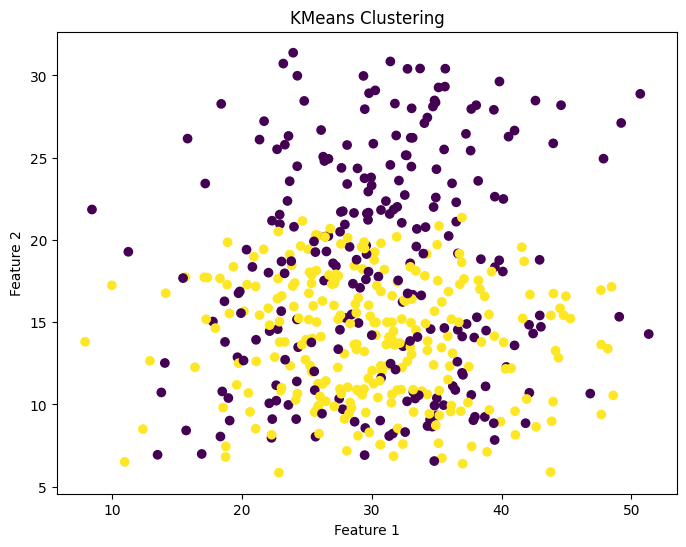

In [ ]:
x=np.array(X)
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], c=kmapped_labels, cmap='viridis')
plt.title('KMeans Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Spectral Clustering

Spectral Clustering Silhouette Score: 0.5551
Spectral Clustering Adjusted Rand Index: 1.0000


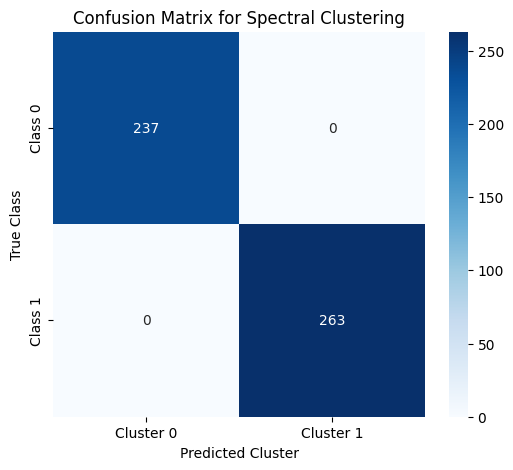

Homogeneity: 1.0000
Completeness: 1.0000
V-measure: 1.0000


In [ ]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors')
spectral_labels = spectral.fit_predict(X)

spectral_silhouette = silhouette_score(X, spectral_labels)
spectral_ari = adjusted_rand_score(y, spectral_labels)

print(f"Spectral Clustering Silhouette Score: {spectral_silhouette:.4f}")
print(f"Spectral Clustering Adjusted Rand Index: {spectral_ari:.4f}")

cm = confusion_matrix(y, spectral_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cluster 0', 'Cluster 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Cluster')
plt.ylabel('True Class')
plt.title('Confusion Matrix for Spectral Clustering')
plt.show()

homogeneity = homogeneity_score(y, spectral_labels)
completeness = completeness_score(y, spectral_labels)
v_measure = v_measure_score(y, spectral_labels)

print(f"Homogeneity: {homogeneity:.4f}")
print(f"Completeness: {completeness:.4f}")
print(f"V-measure: {v_measure:.4f}")

Accuracy: 1.0
Confusion Matrix:
Precision: 1.0
Recall: 1.0
F1-score: 1.0
True Positive Rates (TPRs): [1.0, 1.0]
False Positive Rates (FPRs): [0.0, 0.0]


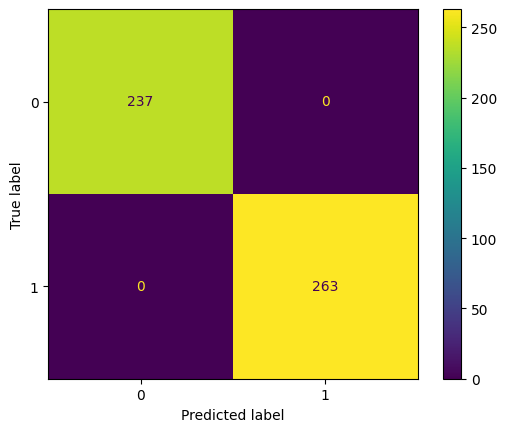

In [ ]:
best_mapping = None
max_accuracy = 0
for mapping in [(0,1),(1,0)]:
    smapped_labels = np.array([mapping[label] for label in spectral_labels])
    accuracy = accuracy_score(y, smapped_labels)
    if accuracy > max_accuracy:
        max_accuracy = accuracy
        best_mapping = mapping

smapped_labels = np.array([best_mapping[label] for label in spectral_labels])
print("Accuracy:", max_accuracy)

cm = confusion_matrix(y, smapped_labels)
print("Confusion Matrix:")
precision = precision_score(y, smapped_labels, average='weighted')
recall = recall_score(y, smapped_labels, average='weighted')
f1 = f1_score(y, smapped_labels, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


tprs = []
fprs = []
for i in range(2):
  tp = cm[i, i]
  fn = np.sum(cm[i, :]) - tp
  fp = np.sum(cm[:, i]) - tp
  tn = np.sum(cm) - tp - fn - fp

  tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
  fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

  tprs.append(tpr)
  fprs.append(fpr)

print("True Positive Rates (TPRs):", tprs)
print("False Positive Rates (FPRs):", fprs)

ConfusionMatrixDisplay.from_predictions(y, smapped_labels)

In [ ]:
def adjacency_matrix_euclidean(x):
  n_points = x.shape[0]
  adjacency_matrix = np.zeros((n_points, n_points))

  for i in range(n_points):
    for j in range(i + 1, n_points):
      distance = np.linalg.norm(x[i] - x[j])
      adjacency_matrix[i, j] = distance
      adjacency_matrix[j, i] = distance

  return adjacency_matrix

x = np.array(X)
adjacency_matrix = adjacency_matrix_euclidean(x)
adjacency_matrix

array([[ 0.        , 18.99847625, 20.85474047, ..., 44.96014457,
        36.28363405, 26.9311641 ],
       [18.99847625,  0.        , 21.54867745, ..., 44.79436014,
        34.75467738, 24.01700023],
       [20.85474047, 21.54867745,  0.        , ..., 26.82526048,
        18.95899523, 10.24781928],
       ...,
       [44.96014457, 44.79436014, 26.82526048, ...,  0.        ,
        11.48637018, 25.23353721],
       [36.28363405, 34.75467738, 18.95899523, ..., 11.48637018,
         0.        , 19.72314123],
       [26.9311641 , 24.01700023, 10.24781928, ..., 25.23353721,
        19.72314123,  0.        ]])

In [ ]:
degree_matrix = np.diag(np.sum(adjacency_matrix, axis=1))
laplacian_matrix = degree_matrix - adjacency_matrix
laplacian_matrix

array([[ 1.33803951e+04, -1.89984763e+01, -2.08547405e+01, ...,
        -4.49601446e+01, -3.62836341e+01, -2.69311641e+01],
       [-1.89984763e+01,  1.31976246e+04, -2.15486775e+01, ...,
        -4.47943601e+01, -3.47546774e+01, -2.40170002e+01],
       [-2.08547405e+01, -2.15486775e+01,  1.06330502e+04, ...,
        -2.68252605e+01, -1.89589952e+01, -1.02478193e+01],
       ...,
       [-4.49601446e+01, -4.47943601e+01, -2.68252605e+01, ...,
         1.46582507e+04, -1.14863702e+01, -2.52335372e+01],
       [-3.62836341e+01, -3.47546774e+01, -1.89589952e+01, ...,
        -1.14863702e+01,  1.26157087e+04, -1.97231412e+01],
       [-2.69311641e+01, -2.40170002e+01, -1.02478193e+01, ...,
        -2.52335372e+01, -1.97231412e+01,  1.05744270e+04]])

In [ ]:
def normalized_laplacian(adjacency_matrix):
  degree_matrix = np.diag(np.sum(adjacency_matrix, axis=1))
  laplacian_matrix = degree_matrix - adjacency_matrix
  degree_matrix_sqrt_inv = np.diag(1.0 / np.sqrt(np.diag(degree_matrix)))
  normalized_laplacian_matrix = np.dot(np.dot(degree_matrix_sqrt_inv, laplacian_matrix), degree_matrix_sqrt_inv)
  return normalized_laplacian_matrix

normalized_laplacian_matrix = normalized_laplacian(adjacency_matrix)
normalized_laplacian_matrix

array([[ 1.00000000e+00, -1.42967202e-03, -1.74840238e-03, ...,
        -3.21034834e-03, -2.79267556e-03, -2.26408244e-03],
       [-1.42967202e-03,  1.00000000e+00, -1.81904651e-03, ...,
        -3.22058213e-03, -2.69345392e-03, -2.03302377e-03],
       [-1.74840238e-03, -1.81904651e-03,  1.00000000e+00, ...,
        -2.14869089e-03, -1.63693170e-03, -9.66438239e-04],
       ...,
       [-3.21034834e-03, -3.22058213e-03, -2.14869089e-03, ...,
         1.00000000e+00, -8.44667744e-04, -2.02678947e-03],
       [-2.79267556e-03, -2.69345392e-03, -1.63693170e-03, ...,
        -8.44667744e-04,  1.00000000e+00, -1.70762238e-03],
       [-2.26408244e-03, -2.03302377e-03, -9.66438239e-04, ...,
        -2.02678947e-03, -1.70762238e-03,  1.00000000e+00]])

Confusion Matrix:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
True Positive Rates (TPRs): [1.0, 1.0]
False Positive Rates (FPRs): [0.0, 0.0]


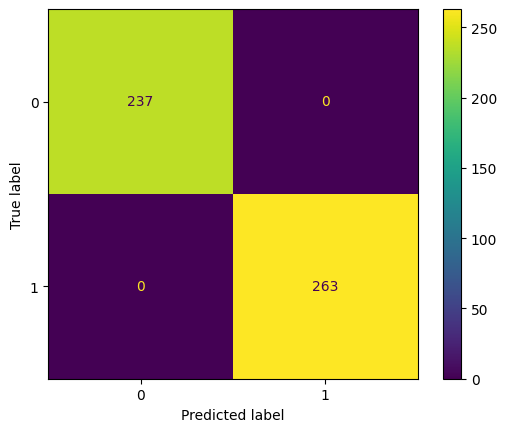

In [ ]:
from numpy import linalg as LA

eigenvalues, eigenvectors = LA.eigh(normalized_laplacian_matrix)

sorted_indices = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

k = 2

eigenvectors_k = eigenvectors[:, :k]

kmeans = KMeans(n_clusters=k)
kmeans.fit(eigenvectors_k)
spectral_labels = kmeans.labels_

best_mapping = None
max_accuracy = 0
for mapping in [(0, 1),(1,0)]:
    mapped_labels = np.array([mapping[label] for label in spectral_labels])
    accuracy = accuracy_score(y, mapped_labels)
    if accuracy > max_accuracy:
        max_accuracy = accuracy
        best_mapping = mapping

cm = confusion_matrix(y, smapped_labels)
print("Confusion Matrix:")

accuracy = accuracy_score(y, smapped_labels)
precision = precision_score(y, smapped_labels, average='weighted')
recall = recall_score(y, smapped_labels, average='weighted')
f1 = f1_score(y, smapped_labels, average='weighted')
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

tprs = []
fprs = []
for i in range(2):
  tp = cm[i, i]
  fn = np.sum(cm[i, :]) - tp
  fp = np.sum(cm[:, i]) - tp
  tn = np.sum(cm) - tp - fn - fp

  tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
  fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

  tprs.append(tpr)
  fprs.append(fpr)

print("True Positive Rates (TPRs):", tprs)
print("False Positive Rates (FPRs):", fprs)

ConfusionMatrixDisplay.from_predictions(y, smapped_labels)

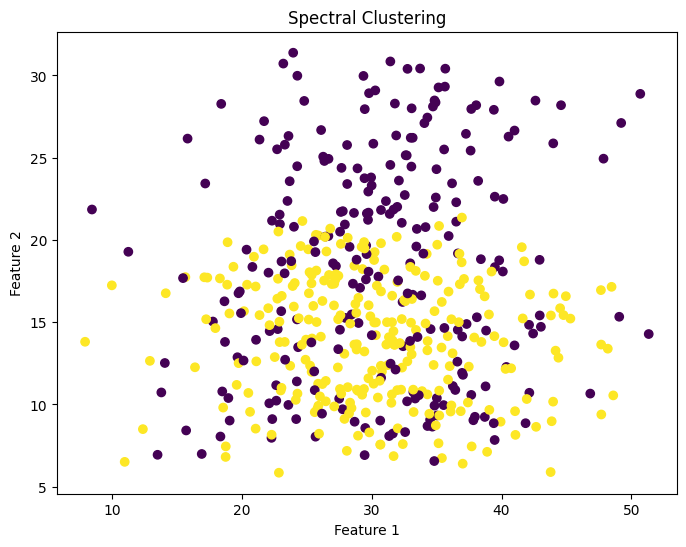

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], c=smapped_labels, cmap='viridis')
plt.title('Spectral Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

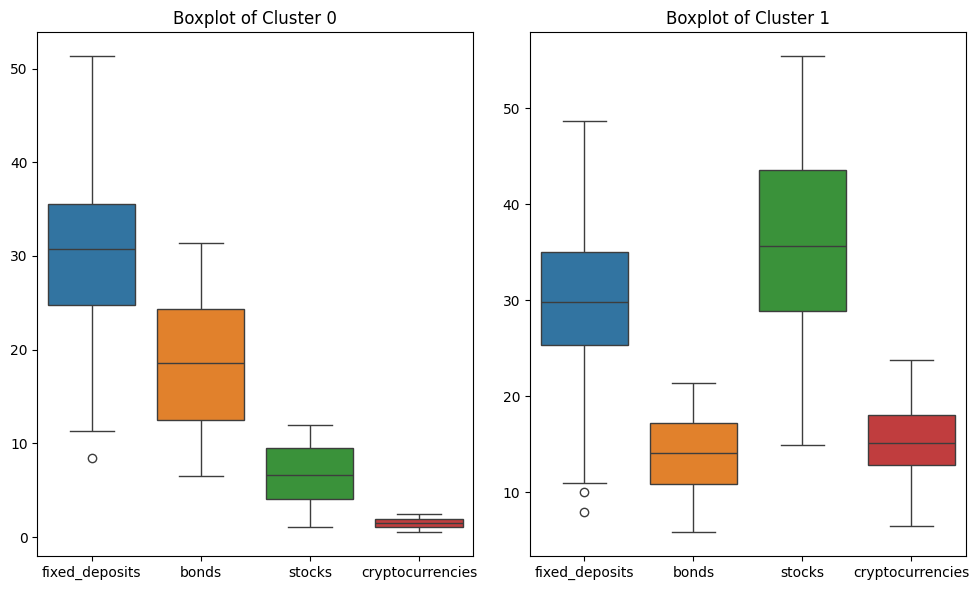

In [ ]:
df_cluster_0 = X[smapped_labels == 0]
df_cluster_1 = X[smapped_labels == 1]

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_cluster_0)
plt.title('Boxplot of Cluster 0')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_cluster_1)
plt.title('Boxplot of Cluster 1')

plt.tight_layout()
plt.show()

In [ ]:
eigenvalues

array([4.08018793e-16, 1.00004321e+00, 1.00004648e+00, 1.00006053e+00,
       1.00006187e+00, 1.00006289e+00, 1.00006516e+00, 1.00006711e+00,
       1.00006840e+00, 1.00006903e+00, 1.00007054e+00, 1.00007103e+00,
       1.00007122e+00, 1.00007155e+00, 1.00007177e+00, 1.00007294e+00,
       1.00007369e+00, 1.00007435e+00, 1.00007545e+00, 1.00007602e+00,
       1.00007652e+00, 1.00007704e+00, 1.00007809e+00, 1.00007819e+00,
       1.00007908e+00, 1.00008066e+00, 1.00008150e+00, 1.00008216e+00,
       1.00008288e+00, 1.00008323e+00, 1.00008334e+00, 1.00008449e+00,
       1.00008498e+00, 1.00008569e+00, 1.00008593e+00, 1.00008654e+00,
       1.00008683e+00, 1.00008709e+00, 1.00008770e+00, 1.00008965e+00,
       1.00008975e+00, 1.00009085e+00, 1.00009112e+00, 1.00009161e+00,
       1.00009210e+00, 1.00009321e+00, 1.00009441e+00, 1.00009555e+00,
       1.00009609e+00, 1.00009698e+00, 1.00009827e+00, 1.00009851e+00,
       1.00009874e+00, 1.00009915e+00, 1.00010075e+00, 1.00010151e+00,
      